In [1]:
import os
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ox.settings.use_cache = True
ox.settings.log_console = False

In [2]:
def preparar_grafo(G):
    # convierte el grafo a no dirigido y conserva solo la componente conectada principal.
    G = ox.convert.to_undirected(G)

    if not nx.is_connected(G):
        componente = max(nx.connected_components(G), key=len)
        G = G.subgraph(componente).copy()

    return G

Ahora vamos a aproximar la centralidad de cercanía usando k nodos pivote. O sea, en vez de calcular distancias desde todos los nodos hacia todos los nodos, calcula distancias desde una muestra de nodos y estima qué tan cerca está
cada nodo del resto de la red.

Retorna un diccionario {nodo: closeness_aprox}.

In [3]:
def closeness_aproximada(G, k=80, weight="length", seed=42):
    rng = np.random.default_rng(seed)
    nodos = list(G.nodes)

    k = min(k, len(nodos))
    pivotes = rng.choice(nodos, size=k, replace=False)

    suma_distancias = {n: 0.0 for n in nodos}
    conteo = {n: 0 for n in nodos}

    for p in pivotes:
        distancias = nx.single_source_dijkstra_path_length(
            G,
            p,
            weight=weight
        )

        for nodo, distancia in distancias.items():
            if nodo != p:
                suma_distancias[nodo] += distancia
                conteo[nodo] += 1

    closeness = {}

    for nodo in nodos:
        if conteo[nodo] > 0 and suma_distancias[nodo] > 0:
            distancia_promedio = suma_distancias[nodo] / conteo[nodo]
            closeness[nodo] = 1 / distancia_promedio
        else:
            closeness[nodo] = 0

    return closeness

In [4]:
def calcular_centralidades_rapidas(G, k_bet=80, k_clo=80, seed=42):

    # calcula betweenness aproximada y closeness aproximada.
    G = preparar_grafo(G)

    bet = nx.betweenness_centrality(
        G,
        k=min(k_bet, len(G.nodes)),
        weight="length",
        seed=seed,
        normalized=True
    )

    clo = closeness_aproximada(
        G,
        k=k_clo,
        weight="length",
        seed=seed
    )

    nodos, edges = ox.graph_to_gdfs(G)

    nodos["betweenness"] = nodos.index.map(bet)
    nodos["closeness"] = nodos.index.map(clo)

    p90_bet = nodos["betweenness"].quantile(0.90)
    p90_clo = nodos["closeness"].quantile(0.90)

    nodos_p90 = nodos[
        (nodos["betweenness"] >= p90_bet) &
        (nodos["closeness"] >= p90_clo)
    ].copy()

    return G, nodos, edges, nodos_p90

In [5]:
nunoa = ox.geocode_to_gdf("Ñuñoa, Santiago, Chile").to_crs(epsg=4326)

puntos_criticos = gpd.read_file(
    "datos_geoespaciales/Accidentes/Puntos_criticos_2019.geojson"
).to_crs(epsg=4326)

seguridad = pd.read_csv("datos_geoespaciales/Seguridad/seguridad_santiago.csv")

seguridad = gpd.GeoDataFrame(
    seguridad,
    geometry=gpd.points_from_xy(seguridad["lon"], seguridad["lat"]),
    crs="EPSG:4326"
)

In [6]:
G_nunoa_raw = ox.graph_from_place(
    "Ñuñoa, Santiago, Chile",
    network_type="drive",
    simplify=True
)

G_nunoa, nodos, edges, nodos_p90 = calcular_centralidades_rapidas(
    G_nunoa_raw,
    k_bet=80,
    k_clo=80,
    seed=42
)

print(f"nodos red Ñuñoa:", len(nodos))
print(f"nodos p90 en ambas métricas:", len(nodos_p90))

nodos red Ñuñoa: 2736
nodos p90 en ambas métricas: 91


In [7]:
acc_nunoa = gpd.sjoin(
    puntos_criticos,
    nunoa[["geometry"]],
    how="inner",
    predicate="within"
)

seg_nunoa = gpd.sjoin(
    seguridad,
    nunoa[["geometry"]],
    how="inner",
    predicate="within"
)

inseg_nunoa = seg_nunoa[
    seg_nunoa["seguridad"] <= seg_nunoa["seguridad"].quantile(0.10)
].copy()

print("puntos críticos accidentes en Ñuñoa:", len(acc_nunoa))
print("puntos de alta inseguridad en Ñuñoa:", len(inseg_nunoa))

puntos críticos accidentes en Ñuñoa: 24
puntos de alta inseguridad en Ñuñoa: 337


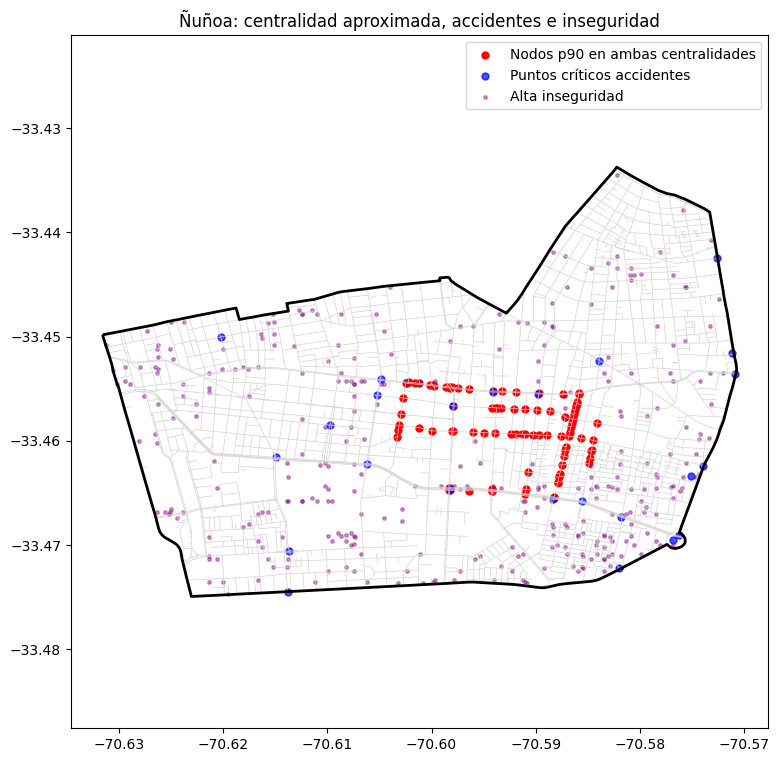

In [8]:
fig, ax = plt.subplots(figsize=(9, 9))

edges.plot(ax=ax, color="lightgray", linewidth=0.5)
nunoa.boundary.plot(ax=ax, color="black", linewidth=2)

nodos_p90.plot(
    ax=ax,
    color="red",
    markersize=25,
    label="Nodos p90 en ambas centralidades"
)

acc_nunoa.plot(
    ax=ax,
    color="blue",
    markersize=25,
    alpha=0.7,
    label="Puntos críticos accidentes"
)

inseg_nunoa.plot(
    ax=ax,
    color="purple",
    markersize=6,
    alpha=0.4,
    label="Alta inseguridad"
)

plt.title("Ñuñoa: centralidad aproximada, accidentes e inseguridad")
plt.legend()
plt.axis("equal")
plt.show()

In [9]:
nunoa_buffer = nunoa.to_crs(epsg=32719)
nunoa_buffer["geometry"] = nunoa_buffer.geometry.buffer(2000)
nunoa_buffer = nunoa_buffer.to_crs(epsg=4326)

In [10]:
G_buffer_raw = ox.graph_from_polygon(
    nunoa_buffer.geometry.iloc[0],
    network_type="drive",
    simplify=True
)

G_buffer, nodos_b, edges_b, nodos_p90_b = calcular_centralidades_rapidas(
    G_buffer_raw,
    k_bet=100,
    k_clo=100,
    seed=42
)

print("Nodos red Ñuñoa + buffer:", len(nodos_b))
print("Nodos p90 en ambas métricas:", len(nodos_p90_b))

Nodos red Ñuñoa + buffer: 9881
Nodos p90 en ambas métricas: 198


In [11]:
nodos_p90_b_en_nunoa = gpd.sjoin(
    nodos_p90_b,
    nunoa[["geometry"]],
    how="inner",
    predicate="within"
)

print("Nodos centrales del análisis con buffer que caen dentro de Ñuñoa:", len(nodos_p90_b_en_nunoa))

Nodos centrales del análisis con buffer que caen dentro de Ñuñoa: 151


In [12]:
acc_buffer = gpd.sjoin(
    puntos_criticos,
    nunoa_buffer[["geometry"]],
    how="inner",
    predicate="within"
)

seg_buffer = gpd.sjoin(
    seguridad,
    nunoa_buffer[["geometry"]],
    how="inner",
    predicate="within"
)

inseg_buffer = seg_buffer[
    seg_buffer["seguridad"] <= seg_buffer["seguridad"].quantile(0.10)
].copy()

print("puntos críticos accidentes en buffer:", len(acc_buffer))
print("puntos de alta inseguridad en buffer:", len(inseg_buffer))

puntos críticos accidentes en buffer: 159
puntos de alta inseguridad en buffer: 1256


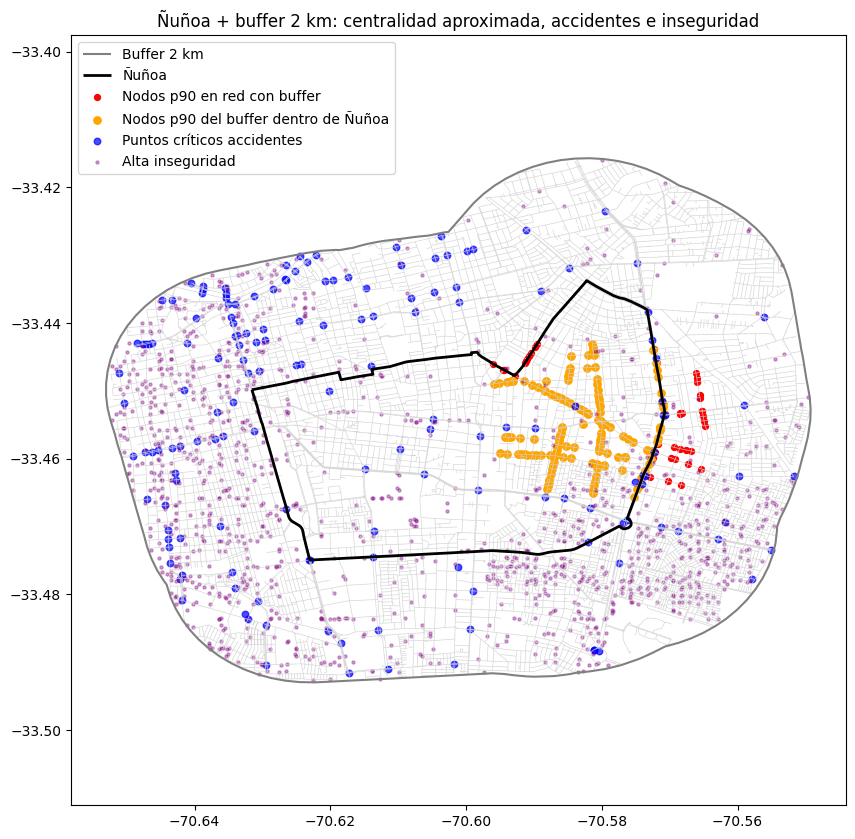

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

edges_b.plot(ax=ax, color="lightgray", linewidth=0.45)

nunoa_buffer.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=1.5,
    label="Buffer 2 km"
)

nunoa.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2,
    label="Ñuñoa"
)

nodos_p90_b.plot(
    ax=ax,
    color="red",
    markersize=18,
    label="Nodos p90 en red con buffer"
)

nodos_p90_b_en_nunoa.plot(
    ax=ax,
    color="orange",
    markersize=28,
    label="Nodos p90 del buffer dentro de Ñuñoa"
)

acc_buffer.plot(
    ax=ax,
    color="blue",
    markersize=22,
    alpha=0.7,
    label="Puntos críticos accidentes"
)

inseg_buffer.plot(
    ax=ax,
    color="purple",
    markersize=5,
    alpha=0.35,
    label="Alta inseguridad"
)

plt.title("Ñuñoa + buffer 2 km: centralidad aproximada, accidentes e inseguridad")
plt.legend()
plt.axis("equal")
plt.show()

In [14]:
comparacion = pd.DataFrame([
    {
        "escenario": "Ñuñoa",
        "nodos_red": len(nodos),
        "nodos_p90": len(nodos_p90),
        "nodos_p90_dentro_nunoa": len(nodos_p90),
        "accidentes": len(acc_nunoa),
        "alta_inseguridad": len(inseg_nunoa)
    },
    {
        "escenario": "Ñuñoa + buffer 2 km",
        "nodos_red": len(nodos_b),
        "nodos_p90": len(nodos_p90_b),
        "nodos_p90_dentro_nunoa": len(nodos_p90_b_en_nunoa),
        "accidentes": len(acc_buffer),
        "alta_inseguridad": len(inseg_buffer)
    }
])

display(comparacion)

,escenario,nodos_red,nodos_p90,nodos_p90_dentro_nunoa,accidentes,alta_inseguridad
0,Ñuñoa,2736,91,91,24,337
1,Ñuñoa + buffer 2 km,9881,198,151,159,1256


Al analizar solo la comuna de Ñuñoa, se identifican 91 nodos que se ubican simultáneamente sobre el percentil 90 de betweenness y closeness. 

Al incorporar un buffer de 2 km, la red aumenta considerablemente de tamaño, pasando de 2736 a 9881 nodos, y se identifican 198 nodos centrales bajo el mismo criterio.

De esos 198 nodos centrales calculados en la red ampliada, 151 se encuentran dentro de Ñuñoa. Esto muestra que varios nodos internos de la comuna siguen siendo relevantes incluso cuando se considera su contexto metropolitano cercano. 

Sin embargo, el cambio respecto al análisis sin buffer indica que la centralidad de ciertos nodos depende del recorte espacial usado. En particular, el buffer reduce el efecto de borde y permite capturar conexiones externas que pueden modificar la importancia relativa de algunos puntos de la red vial.